# AISKG vs PubTator 3.0 vs a structured-output LLM

**Reproducible held-out biomedical extraction benchmark (Google Colab)**

This notebook checks out the audited AISKG GitHub commit, extracts the frozen 150-sentence held-out benchmark, and evaluates:

1. **AISKG** — frozen repository predictions (no re-tuning);
2. **PubTator 3.0** — annotations retrieved from the official NCBI service and projected onto the same sentences;
3. **Structured-output LLM** — a deterministic, zero-shot, ontology-constrained local instruction model.

It produces strict and overlap entity scores, directed relation scores, PubTator endpoint-pair recovery, class coverage, invalid-output rates, sentence-cluster bootstrap confidence intervals, paired bootstrap differences, exact McNemar tests with Holm correction, figures, an Excel workbook, a run manifest, and manuscript-ready text.

## Important design decisions

- The gold labels and AISKG predictions are **frozen before baseline execution**.
- PubTator does not support every AISKG-specific class or predicate. The primary three-system entity comparison is therefore restricted to the **common supported schema**. Full-domain results are separately reported for AISKG and the LLM.
- PubTator strict relation scoring is reported only for predicates that can be defensibly cross-walked. Predicate-agnostic endpoint-pair recovery is also reported and is labelled as such.
- The LLM receives no gold examples and uses temperature 0. This avoids held-out-test leakage.
- Run the final analysis once with `SMOKE_TEST=False`; never report smoke-test results.

Expected runtime: PubTator retrieval typically takes minutes; a 7B local model over 150 sentences may take roughly 1–3 hours on a Colab T4, depending on availability and generation length.

In [1]:
#@title 1. Configuration (edit only this cell before the frozen run)
REPO_URL = "https://github.com/romenmeitei/AISKG.git"
AUDITED_COMMIT = "0e9e0e979c98664c74d7f27e318a7a06aed4fa54"
FROZEN_ZIP = "data/frozen/AISKG_Section2_Inputs_v2.1.1.zip"
SEED = 20260817

SMOKE_TEST = False            # True = first 5 sentences only; NEVER report these results
RUN_PUBTATOR = True
RUN_LLM = True
FORCE_REFRESH_PUBTATOR = True   # keep True for the first corrected run; then False permits resume
FORCE_RERUN_LLM = True          # keep True for the first corrected run; then False permits resume
N_BOOT = 5000                 # 500 for smoke test; 5000 for manuscript run

# Local, reproducible structured-output baseline. A T4 GPU is recommended.
LLM_MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
LLM_MODEL_REVISION = "main"   # pin to a Hugging Face commit hash for the final archived run if desired
MAX_NEW_TOKENS = 700

from pathlib import Path
ROOT = Path("/content/AISKG_three_system_benchmark")
REPO = ROOT / "repo"
WORK = ROOT / "work"
CACHE = ROOT / "cache"
OUTPUT = ROOT / "outputs"
for p in (ROOT, WORK, CACHE, OUTPUT): p.mkdir(parents=True, exist_ok=True)

print("FINAL RUN" if not SMOKE_TEST else "SMOKE TEST ONLY")

FINAL RUN


In [2]:
#@title 2. Install dependencies and initialize environment

# Gradio is preinstalled in some Colab runtimes but is not used here.
# Removing it prevents a huggingface-hub dependency conflict.

%pip uninstall -y -q gradio gradio-client

%pip install -q --upgrade \
    "transformers>=4.46,<5" \
    "accelerate>=1.1" \
    "bitsandbytes>=0.44" \
    "huggingface-hub>=0.26,<1" \
    sentencepiece \
    openpyxl \
    statsmodels \
    seaborn \
    scipy \
    requests \
    tqdm

import os
import re
import json
import math
import time
import hashlib
import random
import shutil
import subprocess
import sys
import zipfile
import warnings

from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import linear_sum_assignment
from scipy.stats import binomtest
from statsmodels.stats.multitest import multipletests
from tqdm.auto import tqdm


# -------------------------------------------------------------------------
# Reproducibility
# -------------------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(
    style="whitegrid",
    context="talk",
)

pd.set_option(
    "display.max_colwidth",
    120,
)


# -------------------------------------------------------------------------
# Utility functions
# -------------------------------------------------------------------------

def sha256_file(path):
    """Calculate the SHA-256 checksum of a file."""

    path = Path(path)
    digest = hashlib.sha256()

    with path.open("rb") as handle:
        for block in iter(
            lambda: handle.read(1 << 20),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def norm_text(x):
    """Normalize text for case-insensitive comparison."""

    if x is None or pd.isna(x):
        return ""

    return re.sub(
        r"\s+",
        " ",
        str(x).strip(),
    ).casefold()


def norm_label(x):
    """Normalize ontology and relation labels."""

    if x is None or pd.isna(x):
        return ""

    return re.sub(
        r"[^A-Z0-9]+",
        "_",
        str(x).upper(),
    ).strip("_")


def jsonl_append(path, obj):
    """Append one JSON record to a JSONL file."""

    path = Path(path)
    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    with path.open(
        "a",
        encoding="utf-8",
    ) as handle:
        handle.write(
            json.dumps(
                obj,
                ensure_ascii=False,
            )
            + "\n"
        )


# -------------------------------------------------------------------------
# Verify essential package availability
# -------------------------------------------------------------------------

import torch
import transformers
import accelerate

try:
    import bitsandbytes as bnb
    bitsandbytes_version = bnb.__version__
except Exception as error:
    bitsandbytes_version = f"Import failed: {error}"


print("Environment initialized successfully.")
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("BitsAndBytes:", bitsandbytes_version)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    warnings.warn(
        "No GPU was detected. Select Runtime → Change runtime type → GPU "
        "before loading the 7B LLM."
    )

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
Environment i

In [3]:
#@title 3. Checkout audited repository commit and extract frozen benchmark
if not (REPO / ".git").exists():
    subprocess.run(["git","clone",REPO_URL,str(REPO)],check=True)
subprocess.run(["git","-C",str(REPO),"fetch","--all","--tags"],check=True)
subprocess.run(["git","-C",str(REPO),"checkout","--detach",AUDITED_COMMIT],check=True)
head=subprocess.check_output(["git","-C",str(REPO),"rev-parse","HEAD"],text=True).strip()
assert head == AUDITED_COMMIT, (head,AUDITED_COMMIT)

zip_path=REPO/FROZEN_ZIP
assert zip_path.exists(), zip_path
frozen_dir=WORK/"frozen"
if frozen_dir.exists(): shutil.rmtree(frozen_dir)
with zipfile.ZipFile(zip_path) as z: z.extractall(frozen_dir)

DATA=frozen_dir/"data"
sentences=pd.read_csv(DATA/"heldout_sentences.csv",dtype={"pmid":str})
gold_e=pd.read_csv(DATA/"heldout_gold_entities.csv")
gold_r=pd.read_csv(DATA/"heldout_gold_relations.csv")
aiskg_e=pd.read_csv(DATA/"heldout_proposed_entity_predictions.csv")
aiskg_r=pd.read_csv(DATA/"heldout_proposed_relation_predictions.csv")

assert len(sentences)==150 and sentences.benchmark_sentence_id.is_unique
assert len(gold_e)==318 and len(gold_r)==56
assert set(gold_e.benchmark_sentence_id)<=set(sentences.benchmark_sentence_id)
assert set(gold_r.benchmark_sentence_id)<=set(sentences.benchmark_sentence_id)

if SMOKE_TEST:
    ids=set(sentences.head(5).benchmark_sentence_id)
    sentences=sentences[sentences.benchmark_sentence_id.isin(ids)].copy()
    gold_e=gold_e[gold_e.benchmark_sentence_id.isin(ids)].copy()
    gold_r=gold_r[gold_r.benchmark_sentence_id.isin(ids)].copy()
    aiskg_e=aiskg_e[aiskg_e.benchmark_sentence_id.isin(ids)].copy()
    aiskg_r=aiskg_r[aiskg_r.benchmark_sentence_id.isin(ids)].copy()
    N_BOOT=min(N_BOOT,500)

print({"commit":head,"sentences":len(sentences),"gold_entities":len(gold_e),"gold_relations":len(gold_r),
       "frozen_zip_sha256":sha256_file(zip_path)})
display(gold_e.entity_type_shared.value_counts().rename("gold_count"))
display(gold_r.relation_label.value_counts().rename("gold_count"))

{'commit': '0e9e0e979c98664c74d7f27e318a7a06aed4fa54', 'sentences': 150, 'gold_entities': 318, 'gold_relations': 56, 'frozen_zip_sha256': '11034f559a447f46ec0ba8118572fb6a54297de04af638f34a6ff87dd41367cc'}


,gold_count
entity_type_shared,
CHEMICAL,162
ORGAN,47
SPECIES,33
DISEASE,32
OTHER,29
GENE_PROTEIN,11
MECHANISM,4


,gold_count
relation_label,
AFFECTS,18
INVOLVES_ORGAN,15
INHIBITS,6
TREATS,5
CONTAINS,4
CAUSES,3
COUNTERACTS_TOXIN,3
ACTS_THROUGH_MECHANISM,2


In [4]:
# Identify records with legitimate PubMed identifiers.
#
# Valid records are:
# 1. records originally obtained from PubMed; or
# 2. Scopus records whose document_id explicitly begins with PMID_.
#
# DOI_ and EID_ records must not be interpreted as PMIDs.

def has_valid_pubmed_identifier(row):
    source = str(row.get("source", "")).strip().casefold()
    document_id = str(row.get("document_id", "")).strip()

    if source == "pubmed":
        return bool(
            re.fullmatch(
                r"\d{6,9}",
                str(row.get("pmid", "")).strip(),
            )
        )

    if document_id.upper().startswith("PMID_"):
        return bool(
            re.fullmatch(
                r"\d{6,9}",
                str(row.get("pmid", "")).strip(),
            )
        )

    return False


sentences["pubtator_eligible"] = sentences.apply(
    has_valid_pubmed_identifier,
    axis=1,
)

PUBTATOR_ELIGIBLE_IDS = set(
    sentences.loc[
        sentences["pubtator_eligible"],
        "benchmark_sentence_id",
    ]
)

PUBTATOR_INELIGIBLE_IDS = set(
    sentences.loc[
        ~sentences["pubtator_eligible"],
        "benchmark_sentence_id",
    ]
)

print(
    "PubTator-eligible sentences:",
    len(PUBTATOR_ELIGIBLE_IDS),
)

print(
    "PubTator-ineligible sentences:",
    len(PUBTATOR_INELIGIBLE_IDS),
)

display(
    sentences.loc[
        ~sentences["pubtator_eligible"],
        [
            "benchmark_sentence_id",
            "source",
            "pmid",
            "document_id",
            "title",
        ],
    ]
)

PubTator-eligible sentences: 146
PubTator-ineligible sentences: 4


,benchmark_sentence_id,source,pmid,document_id,title
22,BMS-0023,Scopus,10,DOI_10.1016_j.myc.2017.03.003,"Amatoxin and phallotoxin concentrations in Amanita fuliginea: Influence of tissues, developmental stages and collect..."
37,BMS-0038,Scopus,10,DOI_10.1134_s1061934824701715,"HPLC–MS/MS Methods for Detecting Muscarine, Muscimol, and Ibotenic Acid in Fungal Samples and Biological Matrices"
74,BMS-0075,Scopus,2,EID_2-s2.0-84950274673,What is the restoring role of chrysin in alpha amanitin toxicity
129,BMS-0130,Scopus,10,DOI_10.1016_j.microc.2025.115447,A portable CuNPs-based nanozyme strip for on-site detection of α-amanitin in wild mushrooms


In [5]:
#@title 4. Normalize sentence-local mentions and construct frozen gold/AISKG records

ENTITY_MAP = {
    "TOXIN": "CHEMICAL",
    "INTERVENTION": "CHEMICAL",
    "CHEMICAL": "CHEMICAL",
    "SYNDROME": "DISEASE",
    "DISEASE": "DISEASE",
    "OUTCOME": "DISEASE",
    "SPECIES": "SPECIES",
    "ORGANISM": "SPECIES",
    "GENE": "GENE_PROTEIN",
    "PROTEIN": "GENE_PROTEIN",
    "GENE_PROTEIN": "GENE_PROTEIN",
    "ORGAN": "ORGAN",
    "MECHANISM": "MECHANISM",
    "CELL": "CELL",
    "CELL_LINE": "CELL_LINE",
    "VARIANT": "VARIANT",
    "OTHER": "OTHER",
}

REL_MAP = {
    "AFFECTS_ORGAN": "AFFECTS",
    "AFFECTS": "AFFECTS",
    "INVOLVES_ORGAN": "INVOLVES_ORGAN",
    "INHIBITS": "INHIBITS",
    "TREATS_SYNDROME": "TREATS",
    "TREATS": "TREATS",
    "CONTAINS_TOXIN": "CONTAINS",
    "CONTAINS": "CONTAINS",
    "CAUSES_SYNDROME": "CAUSES",
    "CAUSES": "CAUSES",
    "COUNTERACTS_TOXIN": "COUNTERACTS_TOXIN",
    "ACTS_THROUGH_MECHANISM": "ACTS_THROUGH_MECHANISM",
}


# -------------------------------------------------------------------------
# Sentence lookup
# -------------------------------------------------------------------------

assert sentences["benchmark_sentence_id"].is_unique

sent_lookup = (
    sentences
    .set_index("benchmark_sentence_id")["sentence_text"]
    .astype(str)
    .to_dict()
)


# -------------------------------------------------------------------------
# Locked held-out text normalization
# -------------------------------------------------------------------------

def heldout_normalize_text(value):
    """
    Reproduce the normalization used by the frozen AISKG held-out
    relation benchmark.
    """

    if value is None or pd.isna(value):
        return ""

    text = str(value)

    text = (
        text
        .replace("α", "alpha")
        .replace("β", "beta")
        .replace("γ", "gamma")
    )

    return re.sub(
        r"\s+",
        " ",
        text.casefold(),
    ).strip()


def all_occurrences(text, mention):
    """Return direct case-insensitive occurrences."""

    if text is None or mention is None:
        return []

    text = str(text)
    mention = str(mention)

    if not mention.strip():
        return []

    return [
        match.span()
        for match in re.finditer(
            re.escape(mention),
            text,
            flags=re.IGNORECASE,
        )
    ]


def normalized_occurrences(text, mention):
    """
    Locate mentions after normalizing Greek letters and whitespace.

    This reproduces the locked AISKG held-out relation projection rule.
    """

    if text is None or mention is None:
        return []

    text = str(text)
    mention = str(mention)

    if not mention.strip():
        return []

    direct_matches = all_occurrences(
        text,
        mention,
    )

    if direct_matches:
        return direct_matches

    replacements = {
        "α": "alpha",
        "β": "beta",
        "γ": "gamma",
    }

    normalized_characters = []
    original_character_map = []

    for original_index, character in enumerate(text):
        projected_piece = replacements.get(
            character,
            character.casefold(),
        )

        for projected_character in projected_piece:
            normalized_characters.append(
                projected_character
            )

            original_character_map.append(
                original_index
            )

    normalized_text = "".join(
        normalized_characters
    )

    normalized_mention = heldout_normalize_text(
        mention
    )

    compact_text_characters = []
    compact_original_map = []

    for normalized_index, character in enumerate(
        normalized_text
    ):
        if not character.isspace():
            compact_text_characters.append(
                character
            )

            compact_original_map.append(
                original_character_map[
                    normalized_index
                ]
            )

    compact_text = "".join(
        compact_text_characters
    )

    compact_mention = re.sub(
        r"\s+",
        "",
        normalized_mention,
    )

    if not compact_mention:
        return []

    spans = []

    for match in re.finditer(
        re.escape(compact_mention),
        compact_text,
    ):
        original_start = compact_original_map[
            match.start()
        ]

        original_end = (
            compact_original_map[
                match.end() - 1
            ]
            + 1
        )

        spans.append(
            (
                original_start,
                original_end,
            )
        )

    return spans


# -------------------------------------------------------------------------
# General entity-span locator
# -------------------------------------------------------------------------

def locate(
    text,
    mention,
    start=None,
    end=None,
):
    """
    Locate a mention using:
    1. supplied valid offsets;
    2. direct matching;
    3. normalized Greek-letter/whitespace matching.
    """

    if text is None or mention is None:
        return None, None

    text = str(text)
    mention = str(mention).strip()

    if not mention:
        return None, None

    # Check supplied offsets first.
    try:
        supplied_start = int(
            float(start)
        )

        supplied_end = int(
            float(end)
        )

        if (
            0 <= supplied_start
            < supplied_end
            <= len(text)
        ):
            offset_text = text[
                supplied_start:
                supplied_end
            ]

            if (
                heldout_normalize_text(offset_text)
                == heldout_normalize_text(mention)
            ):
                return (
                    supplied_start,
                    supplied_end,
                )

    except (
        TypeError,
        ValueError,
        OverflowError,
    ):
        pass

    matches = normalized_occurrences(
        text,
        mention,
    )

    if matches:
        return matches[0]

    return None, None


# -------------------------------------------------------------------------
# Prepare entity records
# -------------------------------------------------------------------------

ENTITY_COLUMNS = [
    "benchmark_sentence_id",
    "system",
    "text",
    "type",
    "start",
    "end",
    "canonical",
]


def prepare_entities(
    df,
    system,
    text_col,
    type_col,
    start_col=None,
    end_col=None,
    canon_col=None,
):
    rows = []

    for _, row in df.iterrows():
        sid = row[
            "benchmark_sentence_id"
        ]

        if sid not in sent_lookup:
            continue

        mention = row[text_col]

        if pd.isna(mention):
            continue

        mention = str(mention).strip()

        if not mention:
            continue

        supplied_start = (
            row.get(start_col)
            if start_col is not None
            else None
        )

        supplied_end = (
            row.get(end_col)
            if end_col is not None
            else None
        )

        start, end = locate(
            sent_lookup[sid],
            mention,
            supplied_start,
            supplied_end,
        )

        raw_type = norm_label(
            row[type_col]
        )

        shared_type = ENTITY_MAP.get(
            raw_type,
            raw_type,
        )

        canonical = mention

        if canon_col is not None:
            canonical_value = row.get(
                canon_col
            )

            if (
                canonical_value is not None
                and not pd.isna(canonical_value)
                and str(canonical_value).strip()
            ):
                canonical = str(
                    canonical_value
                ).strip()

        rows.append(
            {
                "benchmark_sentence_id":
                    sid,
                "system":
                    system,
                "text":
                    mention,
                "type":
                    shared_type,
                "start":
                    start,
                "end":
                    end,
                "canonical":
                    canonical,
            }
        )

    result = pd.DataFrame(
        rows,
        columns=ENTITY_COLUMNS,
    )

    return (
        result
        .drop_duplicates(
            subset=[
                "benchmark_sentence_id",
                "type",
                "start",
                "end",
                "text",
            ]
        )
        .reset_index(drop=True)
    )


gold_entities = prepare_entities(
    df=gold_e,
    system="GOLD",
    text_col="entity_text",
    type_col="entity_type_shared",
    start_col="char_start_optional",
    end_col="char_end_optional",
    canon_col="canonical_name_optional",
)

aiskg_entities = prepare_entities(
    df=aiskg_e,
    system="AISKG",
    text_col="matched_text",
    type_col="entity_type",
    start_col="char_start",
    end_col="char_end",
    canon_col="canonical_entity",
)


# -------------------------------------------------------------------------
# Sentence-scoped gold entity lookup
# -------------------------------------------------------------------------

duplicate_gold_entity_ids = gold_e.duplicated(
    subset=[
        "benchmark_sentence_id",
        "entity_id",
    ],
    keep=False,
)

if duplicate_gold_entity_ids.any():
    raise ValueError(
        "Duplicate sentence-scoped gold entity IDs were found."
    )


entity_by_id = {}

for _, row in gold_e.iterrows():
    sid = row[
        "benchmark_sentence_id"
    ]

    if sid not in sent_lookup:
        continue

    start, end = locate(
        sent_lookup[sid],
        row["entity_text"],
        row.get("char_start_optional"),
        row.get("char_end_optional"),
    )

    raw_type = norm_label(
        row["entity_type_shared"]
    )

    entity_by_id[
        (
            str(sid),
            str(row["entity_id"]),
        )
    ] = {
        "text":
            str(row["entity_text"]).strip(),
        "type":
            ENTITY_MAP.get(
                raw_type,
                raw_type,
            ),
        "start":
            start,
        "end":
            end,
    }


expected_unique_entities = (
    gold_e[
        [
            "benchmark_sentence_id",
            "entity_id",
        ]
    ]
    .astype(str)
    .drop_duplicates()
    .shape[0]
)

assert (
    len(entity_by_id)
    == expected_unique_entities
), (
    "Gold (benchmark_sentence_id, entity_id) "
    "pairs must be unique."
)


# -------------------------------------------------------------------------
# Construct gold relation records
# -------------------------------------------------------------------------

RELATION_COLUMNS = [
    "benchmark_sentence_id",
    "system",
    "source",
    "source_type",
    "relation",
    "target",
    "target_type",
]


gold_relation_rows = []
unresolved_gold_relations = []

for _, row in gold_r.iterrows():
    sid = str(
        row["benchmark_sentence_id"]
    )

    source_entity = entity_by_id.get(
        (
            sid,
            str(row["source_entity_id"]),
        )
    )

    target_entity = entity_by_id.get(
        (
            sid,
            str(row["target_entity_id"]),
        )
    )

    if (
        source_entity is None
        or target_entity is None
    ):
        unresolved_gold_relations.append(
            {
                "benchmark_sentence_id":
                    sid,
                "relation_id":
                    row["relation_id"],
                "source_entity_id":
                    row["source_entity_id"],
                "target_entity_id":
                    row["target_entity_id"],
            }
        )

        continue

    raw_relation = norm_label(
        row["relation_label"]
    )

    gold_relation_rows.append(
        {
            "benchmark_sentence_id":
                row["benchmark_sentence_id"],
            "system":
                "GOLD",
            "source":
                source_entity["text"],
            "source_type":
                source_entity["type"],
            "relation":
                REL_MAP.get(
                    raw_relation,
                    raw_relation,
                ),
            "target":
                target_entity["text"],
            "target_type":
                target_entity["type"],
        }
    )


if unresolved_gold_relations:
    display(
        pd.DataFrame(
            unresolved_gold_relations
        )
    )

    raise ValueError(
        "One or more gold relation endpoints "
        "could not be resolved."
    )


gold_relations = pd.DataFrame(
    gold_relation_rows,
    columns=RELATION_COLUMNS,
)

assert len(gold_relations) == 56


# -------------------------------------------------------------------------
# Construct locked strict AISKG relation predictions
# -------------------------------------------------------------------------

aiskg_relation_rows = []
aiskg_relation_projection_audit = []

nonempty_aiskg_relations = aiskg_r.dropna(
    subset=[
        "relation",
        "source_entity",
        "target_entity",
    ]
)

for _, row in nonempty_aiskg_relations.iterrows():
    sid = row[
        "benchmark_sentence_id"
    ]

    if sid not in sent_lookup:
        continue

    raw_relation = norm_label(
        row["relation"]
    )

    mapped_relation = REL_MAP.get(
        raw_relation
    )

    if mapped_relation is None:
        continue

    source_text = str(
        row["source_entity"]
    ).strip()

    target_text = str(
        row["target_entity"]
    ).strip()

    sentence_text = sent_lookup[sid]

    source_occurrences = (
        normalized_occurrences(
            sentence_text,
            source_text,
        )
    )

    target_occurrences = (
        normalized_occurrences(
            sentence_text,
            target_text,
        )
    )

    source_present = bool(
        source_occurrences
    )

    target_present = bool(
        target_occurrences
    )

    aiskg_relation_projection_audit.append(
        {
            "benchmark_sentence_id":
                sid,
            "source_entity":
                source_text,
            "relation":
                row["relation"],
            "target_entity":
                target_text,
            "source_present":
                source_present,
            "target_present":
                target_present,
        }
    )

    # Locked strict surface-form rule:
    # both endpoints must be present in the sentence.
    if (
        not source_present
        or not target_present
    ):
        continue

    source_type_raw = norm_label(
        row["source_type"]
    )

    target_type_raw = norm_label(
        row["target_type"]
    )

    aiskg_relation_rows.append(
        {
            "benchmark_sentence_id":
                sid,
            "system":
                "AISKG",
            "source":
                source_text,
            "source_type":
                ENTITY_MAP.get(
                    source_type_raw,
                    source_type_raw,
                ),
            "relation":
                mapped_relation,
            "target":
                target_text,
            "target_type":
                ENTITY_MAP.get(
                    target_type_raw,
                    target_type_raw,
                ),
        }
    )


aiskg_relations = (
    pd.DataFrame(
        aiskg_relation_rows,
        columns=RELATION_COLUMNS,
    )
    .drop_duplicates(
        subset=[
            "benchmark_sentence_id",
            "source",
            "relation",
            "target",
        ]
    )
    .reset_index(drop=True)
)

aiskg_relation_projection_audit = (
    pd.DataFrame(
        aiskg_relation_projection_audit
    )
)

excluded_relation_candidates = (
    ~(
        aiskg_relation_projection_audit[
            "source_present"
        ]
        & aiskg_relation_projection_audit[
            "target_present"
        ]
    )
).sum()


# -------------------------------------------------------------------------
# Final checks
# -------------------------------------------------------------------------

print(
    "Gold sentence-scoped entity IDs:",
    len(entity_by_id),
)

print(
    "Gold relations successfully constructed:",
    len(gold_relations),
    "/",
    len(gold_r),
)

print(
    "Located gold spans:",
    gold_entities["start"].notna().sum(),
    "/",
    len(gold_entities),
)

print(
    "Located AISKG spans:",
    aiskg_entities["start"].notna().sum(),
    "/",
    len(aiskg_entities),
)

print(
    "AISKG raw non-empty relation candidates:",
    len(nonempty_aiskg_relations),
)

print(
    "AISKG strict sentence-projected relations:",
    len(aiskg_relations),
)

print(
    "AISKG relation candidates excluded:",
    int(excluded_relation_candidates),
)


assert len(entity_by_id) == 318
assert len(gold_relations) == 56
assert len(gold_entities) == 318
assert len(aiskg_entities) == 272
assert len(nonempty_aiskg_relations) == 50

assert len(aiskg_relations) == 27, (
    "The frozen strict AISKG relation benchmark "
    "must contain exactly 27 sentence-projected predictions."
)

assert int(excluded_relation_candidates) == 23

print("\nCell 4 validation passed.")

Gold sentence-scoped entity IDs: 318
Gold relations successfully constructed: 56 / 56
Located gold spans: 318 / 318
Located AISKG spans: 272 / 272
AISKG raw non-empty relation candidates: 50
AISKG strict sentence-projected relations: 27
AISKG relation candidates excluded: 23

Cell 4 validation passed.


In [6]:
print(
    "Gold sentence-scoped entity IDs:",
    len(entity_by_id),
)

print(
    "Gold relations successfully constructed:",
    len(gold_relations),
    "/",
    len(gold_r),
)

print(
    "Missing gold relation endpoints:",
    len(gold_r) - len(gold_relations),
)

assert len(entity_by_id) == 318
assert len(gold_relations) == 56

print("\nCell 4 validation passed.")

Gold sentence-scoped entity IDs: 318
Gold relations successfully constructed: 56 / 56
Missing gold relation endpoints: 0

Cell 4 validation passed.


## PubTator 3.0 retrieval

The service is queried by PMID and the raw BioC JSON response is cached. Because PubTator returns document-level annotations, every entity is independently re-projected onto the frozen target sentence. A relation is retained only if both referenced annotations can be projected into that same sentence. The parser tries the current PubTator 3 endpoint first and a legacy-compatible NCBI endpoint second; failures remain visible in the coverage report.

In [7]:
#@title 5. Retrieve and parse PubTator 3.0 (corrected, resumable and auditable)

# -------------------------------------------------------------------------
# PubTator endpoints
# -------------------------------------------------------------------------

PUB_ENDPOINTS = [
    (
        "PubTator3",
        "https://www.ncbi.nlm.nih.gov/research/"
        "pubtator3-api/publications/export/biocjson"
    ),
    (
        "PubTator-Legacy",
        "https://www.ncbi.nlm.nih.gov/research/"
        "pubtator-api/publications/export/biocjson"
    ),
]


# -------------------------------------------------------------------------
# PubTator entity-type crosswalk
# -------------------------------------------------------------------------

PUB_TYPE = {
    "chemical": "CHEMICAL",
    "chemicals": "CHEMICAL",
    "drug": "CHEMICAL",
    "disease": "DISEASE",
    "diseases": "DISEASE",
    "species": "SPECIES",
    "organism": "SPECIES",
    "gene": "GENE_PROTEIN",
    "genes": "GENE_PROTEIN",
    "protein": "GENE_PROTEIN",
    "geneprotein": "GENE_PROTEIN",
    "gene_protein": "GENE_PROTEIN",
    "cellline": "CELL_LINE",
    "cell_line": "CELL_LINE",
    "cell line": "CELL_LINE",
    "variant": "VARIANT",
    "mutation": "VARIANT",
    "snp": "VARIANT",
}


# -------------------------------------------------------------------------
# PubTator relation crosswalk
#
# Only relations with a defensible mapping to the AISKG relation ontology
# are used for strict predicate-level scoring.
# -------------------------------------------------------------------------

PUB_REL = {
    "treatment": "TREATS",
    "treats": "TREATS",
    "therapy": "TREATS",
    "cause": "CAUSES",
    "causes": "CAUSES",
    "causal": "CAUSES",
    "inhibit": "INHIBITS",
    "inhibits": "INHIBITS",
    "inhibition": "INHIBITS",
    "contain": "CONTAINS",
    "contains": "CONTAINS",
    "contained_in": "CONTAINS",
}


# -------------------------------------------------------------------------
# Cache locations
# -------------------------------------------------------------------------

PUBTATOR_CACHE_FILE = CACHE / "pubtator_bioc.json"

PUBTATOR_DIAGNOSTIC_FILE = (
    CACHE / "pubtator_request_diagnostics.json"
)


# -------------------------------------------------------------------------
# PMID normalization
# -------------------------------------------------------------------------

def pmid_key(value):
    """
    Convert PMID-like values into a normalized numeric string.

    Examples
    --------
    '22885396'     -> '22885396'
    '22885396.0'   -> '22885396'
    'PMID:22885396' -> '22885396'
    """

    if value is None or pd.isna(value):
        return ""

    match = re.search(
        r"\d+",
        str(value),
    )

    if match:
        return match.group(0)

    return str(value).strip()


# -------------------------------------------------------------------------
# Entity-type normalization
# -------------------------------------------------------------------------

def normalize_pubtator_type(value):
    """
    Normalize a PubTator entity type and apply the shared-schema crosswalk.
    """

    if value is None or pd.isna(value):
        return None

    raw_type = str(value).strip().casefold()

    candidates = [
        raw_type,
        raw_type.replace("-", "_"),
        raw_type.replace(" ", "_"),
        raw_type.replace("-", ""),
        raw_type.replace("_", ""),
        raw_type.replace(" ", ""),
    ]

    for candidate in candidates:
        if candidate in PUB_TYPE:
            return PUB_TYPE[candidate]

    return None


# -------------------------------------------------------------------------
# Relation-type normalization
# -------------------------------------------------------------------------

def normalize_pubtator_relation(value):
    """
    Map a native PubTator relation label to the AISKG relation ontology.

    Returns None when no defensible crosswalk is available.
    """

    if value is None or pd.isna(value):
        return None

    raw_relation = str(value).strip().casefold()

    candidates = [
        raw_relation,
        raw_relation.replace("-", "_"),
        raw_relation.replace(" ", "_"),
        raw_relation.replace("-", ""),
        raw_relation.replace("_", ""),
        raw_relation.replace(" ", ""),
    ]

    for candidate in candidates:
        if candidate in PUB_REL:
            return PUB_REL[candidate]

    return None


# -------------------------------------------------------------------------
# Flexible BioC response decoder
# -------------------------------------------------------------------------

def decode_pubtator_response(response):
    """
    Decode standard JSON, BioC JSON or newline-delimited JSON.
    """

    response_text = response.text.strip()

    if not response_text:
        return None

    # Standard JSON response.
    try:
        return response.json()

    except Exception:
        pass

    # Explicit JSON decoding.
    try:
        return json.loads(response_text)

    except Exception:
        pass

    # Newline-delimited JSON fallback.
    records = []

    for line in response_text.splitlines():
        line = line.strip()

        if not line:
            continue

        try:
            records.append(
                json.loads(line)
            )

        except Exception:
            continue

    if records:
        return records

    return None


# -------------------------------------------------------------------------
# Recursive BioC document extraction
# -------------------------------------------------------------------------

def flatten_bioc(payload):
    """
    Recursively extract BioC document objects from arbitrary API wrappers.

    A BioC document is recognized by the presence of a 'passages' list.
    """

    documents = []
    visited_objects = set()

    def walk(obj):
        object_identity = id(obj)

        if object_identity in visited_objects:
            return

        visited_objects.add(object_identity)

        if isinstance(obj, list):
            for item in obj:
                walk(item)

            return

        if not isinstance(obj, dict):
            return

        # A BioC document contains a passages list.
        if isinstance(obj.get("passages"), list):
            documents.append(obj)
            return

        # Recursively inspect every nested value.
        # This avoids dependence on a particular wrapper name.
        for value in obj.values():
            if isinstance(value, (dict, list)):
                walk(value)

    walk(payload)

    return documents


# -------------------------------------------------------------------------
# Extract a PMID from a returned BioC document
# -------------------------------------------------------------------------

def document_pmid_candidates(document):
    """
    Return all plausible PMID identifiers from one BioC document.
    """

    candidates = []

    if not isinstance(document, dict):
        return candidates

    candidates.extend(
        [
            document.get("id"),
            document.get("pmid"),
            document.get("PMID"),
        ]
    )

    infons = document.get(
        "infons",
        {},
    )

    if isinstance(infons, dict):
        candidates.extend(
            [
                infons.get("pmid"),
                infons.get("PMID"),
                infons.get("pubmed"),
                infons.get("PubMed"),
                infons.get("identifier"),
            ]
        )

    normalized = []

    for candidate in candidates:
        key = pmid_key(candidate)

        if key and key not in normalized:
            normalized.append(key)

    return normalized


# -------------------------------------------------------------------------
# Deduplicate returned BioC documents
# -------------------------------------------------------------------------

def deduplicate_pubtator_documents(documents):
    """
    Remove duplicate returned documents while preserving order.
    """

    unique_documents = []
    observed = set()

    for index, document in enumerate(documents):
        pmid_candidates = document_pmid_candidates(
            document
        )

        if pmid_candidates:
            primary_key = pmid_candidates[0]

        else:
            primary_key = (
                "unknown-document-"
                f"{index}-"
                f"{hashlib.sha256(json.dumps(document, sort_keys=True, default=str).encode()).hexdigest()[:16]}"
            )

        if primary_key in observed:
            continue

        observed.add(primary_key)
        unique_documents.append(document)

    return unique_documents


# -------------------------------------------------------------------------
# Retrieve PubTator documents
# -------------------------------------------------------------------------

def fetch_pubtator(pmids):
    """
    Retrieve BioC documents from PubTator.

    Important behavior
    ------------------
    HTTP 200 is accepted as successful only if at least one BioC document
    can be extracted. Otherwise, the fallback endpoint is tried.
    """

    normalized_pmids = sorted(
        {
            pmid_key(pmid)
            for pmid in pmids
            if pmid_key(pmid)
        }
    )

    if not normalized_pmids:
        raise ValueError(
            "No valid PMIDs were supplied to PubTator."
        )

    # Use cache only when it contains actual documents.
    if (
        PUBTATOR_CACHE_FILE.exists()
        and not FORCE_REFRESH_PUBTATOR
    ):
        cached_result = json.loads(
            PUBTATOR_CACHE_FILE.read_text(
                encoding="utf-8"
            )
        )

        cached_documents = cached_result.get(
            "documents",
            [],
        )

        if cached_documents:
            print(
                "Loaded PubTator cache:",
                len(cached_documents),
                "documents.",
            )

            return cached_result

        print(
            "The existing PubTator cache is empty "
            "and will be replaced."
        )

    all_documents = []
    failures = []
    diagnostics = []

    batch_size = 20

    for batch_start in tqdm(
        range(
            0,
            len(normalized_pmids),
            batch_size,
        ),
        desc="PubTator batches",
    ):
        batch = normalized_pmids[
            batch_start:
            batch_start + batch_size
        ]

        batch_succeeded = False

        for endpoint_name, endpoint_url in PUB_ENDPOINTS:
            for attempt in range(1, 6):
                diagnostic = {
                    "batch_start":
                        batch_start,
                    "batch_pmids":
                        batch,
                    "endpoint":
                        endpoint_name,
                    "attempt":
                        attempt,
                }

                try:
                    response = requests.get(
                        endpoint_url,
                        params={
                            "pmids":
                                ",".join(batch)
                        },
                        headers={
                            "User-Agent":
                                "AISKG-reproducible-benchmark/1.0",
                            "Accept":
                                "application/json",
                        },
                        timeout=90,
                    )

                    diagnostic.update(
                        {
                            "status_code":
                                response.status_code,
                            "content_type":
                                response.headers.get(
                                    "content-type",
                                    "",
                                ),
                            "response_length":
                                len(response.content),
                            "response_preview":
                                response.text[:500],
                        }
                    )

                    # Retry temporary HTTP failures.
                    if response.status_code in {
                        429,
                        500,
                        502,
                        503,
                        504,
                    }:
                        diagnostic["result"] = (
                            "temporary_http_error"
                        )

                        diagnostics.append(
                            diagnostic
                        )

                        if attempt < 5:
                            time.sleep(
                                min(
                                    2 ** attempt,
                                    30,
                                )
                            )

                        continue

                    # Try the next endpoint for other HTTP errors.
                    if response.status_code != 200:
                        diagnostic["result"] = (
                            "non_200_response"
                        )

                        diagnostics.append(
                            diagnostic
                        )

                        break

                    payload = decode_pubtator_response(
                        response
                    )

                    extracted_documents = (
                        flatten_bioc(payload)
                        if payload is not None
                        else []
                    )

                    diagnostic[
                        "documents_extracted"
                    ] = len(extracted_documents)

                    # Critical safeguard:
                    # HTTP 200 without documents is not success.
                    if not extracted_documents:
                        diagnostic["result"] = (
                            "http_200_but_no_bioc_documents"
                        )

                        diagnostics.append(
                            diagnostic
                        )

                        # Try the fallback endpoint.
                        break

                    diagnostic["result"] = "success"

                    diagnostics.append(
                        diagnostic
                    )

                    all_documents.extend(
                        extracted_documents
                    )

                    batch_succeeded = True

                    break

                except Exception as error:
                    diagnostic.update(
                        {
                            "result":
                                "request_exception",
                            "error":
                                repr(error),
                        }
                    )

                    diagnostics.append(
                        diagnostic
                    )

                    if attempt < 5:
                        time.sleep(
                            min(
                                2 ** attempt,
                                30,
                            )
                        )

            if batch_succeeded:
                break

        if not batch_succeeded:
            failures.append(
                {
                    "batch_start":
                        batch_start,
                    "pmids":
                        batch,
                    "error":
                        "No BioC documents were extracted "
                        "from either endpoint.",
                }
            )

        time.sleep(0.5)

    unique_documents = (
        deduplicate_pubtator_documents(
            all_documents
        )
    )

    result = {
        "retrieved_at":
            datetime.now(timezone.utc).isoformat(),
        "requested_pmids":
            normalized_pmids,
        "documents":
            unique_documents,
        "failures":
            failures,
    }

    PUBTATOR_CACHE_FILE.write_text(
        json.dumps(
            result,
            ensure_ascii=False,
        ),
        encoding="utf-8",
    )

    PUBTATOR_DIAGNOSTIC_FILE.write_text(
        json.dumps(
            diagnostics,
            indent=2,
            ensure_ascii=False,
        ),
        encoding="utf-8",
    )

    print(
        "Raw BioC documents extracted:",
        len(all_documents),
    )

    print(
        "Unique PubTator documents:",
        len(unique_documents),
    )

    print(
        "Failed PMID batches:",
        len(failures),
    )

    return result


# -------------------------------------------------------------------------
# Parse PubTator entities and relations
# -------------------------------------------------------------------------

def parse_pubtator(bundle):
    """
    Project document-level PubTator annotations onto the frozen sentences.
    """

    documents = bundle.get(
        "documents",
        [],
    )

    by_pmid = {}

    for document in documents:
        for candidate in document_pmid_candidates(
            document
        ):
            by_pmid[candidate] = document

    entity_rows = []
    relation_rows = []
    covered_sentence_ids = []
    matched_document_pmids = set()

    for _, sentence_row in sentences.loc[
    sentences["pubtator_eligible"]
        ].iterrows():
        sentence_id = sentence_row[
            "benchmark_sentence_id"
        ]

        sentence_pmid = pmid_key(
            sentence_row["pmid"]
        )

        sentence_text = str(
            sentence_row["sentence_text"]
        )

        document = by_pmid.get(
            sentence_pmid
        )

        if document is None:
            continue

        covered_sentence_ids.append(
            sentence_id
        )

        matched_document_pmids.add(
            sentence_pmid
        )

        annotation_by_id = {}

        passages = document.get(
            "passages",
            [],
        )

        if not isinstance(passages, list):
            passages = []

        all_relations = list(
            document.get(
                "relations",
                [],
            )
            or []
        )

        for passage in passages:
            if not isinstance(passage, dict):
                continue

            passage_relations = passage.get(
                "relations",
                [],
            )

            if isinstance(passage_relations, list):
                all_relations.extend(
                    passage_relations
                )

            annotations = passage.get(
                "annotations",
                [],
            )

            if not isinstance(annotations, list):
                continue

            for annotation in annotations:
                if not isinstance(annotation, dict):
                    continue

                annotation_id = str(
                    annotation.get(
                        "id",
                        "",
                    )
                )

                infons = annotation.get(
                    "infons",
                    {},
                )

                if not isinstance(infons, dict):
                    infons = {}

                native_type = (
                    infons.get("type")
                    or infons.get("Type")
                    or infons.get("entity_type")
                    or infons.get("category")
                    or ""
                )

                shared_type = (
                    normalize_pubtator_type(
                        native_type
                    )
                )

                mention = str(
                    annotation.get(
                        "text",
                        "",
                    )
                ).strip()

                if not mention:
                    continue

                start, end = locate(
                    sentence_text,
                    mention,
                )

                annotation_by_id[
                    annotation_id
                ] = {
                    "text":
                        mention,
                    "type":
                        shared_type,
                    "start":
                        start,
                    "end":
                        end,
                }

                # Retain only supported types whose mentions
                # occur in the frozen target sentence.
                if (
                    shared_type is not None
                    and start is not None
                    and end is not None
                ):
                    canonical_identifier = (
                        infons.get("identifier")
                        or infons.get("Identifier")
                        or infons.get("database_id")
                        or mention
                    )

                    entity_rows.append(
                        {
                            "benchmark_sentence_id":
                                sentence_id,
                            "system":
                                "PubTator3",
                            "text":
                                mention,
                            "type":
                                shared_type,
                            "start":
                                start,
                            "end":
                                end,
                            "canonical":
                                str(
                                    canonical_identifier
                                ),
                        }
                    )

        # Parse relations only when both referenced entities
        # can be projected into the same frozen sentence.
        for relation in all_relations:
            if not isinstance(relation, dict):
                continue

            infons = relation.get(
                "infons",
                {},
            )

            if not isinstance(infons, dict):
                infons = {}

            native_relation = (
                infons.get("type")
                or infons.get("Type")
                or infons.get("relation")
                or infons.get("relation_type")
                or ""
            )

            mapped_relation = (
                normalize_pubtator_relation(
                    native_relation
                )
            )

            nodes = relation.get(
                "nodes",
                [],
            )

            if not isinstance(nodes, list):
                continue

            node_references = []

            for node in nodes:
                if not isinstance(node, dict):
                    continue

                reference = (
                    node.get("refid")
                    or node.get("ref_id")
                    or node.get("id")
                )

                if reference is not None:
                    node_references.append(
                        str(reference)
                    )

            if len(node_references) < 2:
                continue

            source_annotation = (
                annotation_by_id.get(
                    node_references[0]
                )
            )

            target_annotation = (
                annotation_by_id.get(
                    node_references[1]
                )
            )

            if (
                source_annotation is None
                or target_annotation is None
            ):
                continue

            if (
                source_annotation["start"] is None
                or target_annotation["start"] is None
            ):
                continue

            relation_rows.append(
                {
                    "benchmark_sentence_id":
                        sentence_id,
                    "system":
                        "PubTator3",
                    "source":
                        source_annotation["text"],
                    "source_type":
                        source_annotation["type"],
                    "relation":
                        mapped_relation,
                    "native_relation":
                        str(native_relation),
                    "target":
                        target_annotation["text"],
                    "target_type":
                        target_annotation["type"],
                }
            )

    entity_columns = [
        "benchmark_sentence_id",
        "system",
        "text",
        "type",
        "start",
        "end",
        "canonical",
    ]

    relation_columns = [
        "benchmark_sentence_id",
        "system",
        "source",
        "source_type",
        "relation",
        "native_relation",
        "target",
        "target_type",
    ]

    pubtator_entities = pd.DataFrame(
        entity_rows,
        columns=entity_columns,
    )

    pubtator_entities = (
        pubtator_entities
        .drop_duplicates(
            subset=[
                "benchmark_sentence_id",
                "type",
                "start",
                "end",
            ]
        )
        .reset_index(drop=True)
    )

    pubtator_relations = pd.DataFrame(
        relation_rows,
        columns=relation_columns,
    )

    pubtator_relations = (
        pubtator_relations
        .drop_duplicates()
        .reset_index(drop=True)
    )

    diagnostics = {
        "returned_documents":
            len(documents),
        "matched_unique_pmids":
            len(matched_document_pmids),
        "covered_sentences":
            len(set(covered_sentence_ids)),
        "projected_entities":
            len(pubtator_entities),
        "projected_relations":
            len(pubtator_relations),
    }

    return (
        pubtator_entities,
        pubtator_relations,
        set(covered_sentence_ids),
        diagnostics,
    )


# -------------------------------------------------------------------------
# Execute PubTator retrieval
# -------------------------------------------------------------------------

# Determine whether each record has a genuine PMID. DOI_ and EID_ identifiers
# must not be reduced to the leading values "10" or "2" and queried as PMIDs.
def has_valid_pubmed_identifier(row):
    source = str(row.get("source", "")).strip().casefold()
    document_id = str(row.get("document_id", "")).strip()
    raw_pmid = str(row.get("pmid", "")).strip()

    if source == "pubmed":
        return bool(re.fullmatch(r"\d{6,9}", raw_pmid))

    if document_id.upper().startswith("PMID_"):
        return bool(re.fullmatch(r"\d{6,9}", raw_pmid))

    return False


sentences["pubtator_eligible"] = sentences.apply(
    has_valid_pubmed_identifier,
    axis=1,
)

PUBTATOR_ELIGIBLE_IDS = set(
    sentences.loc[
        sentences["pubtator_eligible"],
        "benchmark_sentence_id",
    ]
)

PUBTATOR_INELIGIBLE_IDS = set(
    sentences.loc[
        ~sentences["pubtator_eligible"],
        "benchmark_sentence_id",
    ]
)

print("PubTator-eligible sentences:", len(PUBTATOR_ELIGIBLE_IDS))
print("PubTator-ineligible sentences:", len(PUBTATOR_INELIGIBLE_IDS))

if PUBTATOR_INELIGIBLE_IDS:
    display(
        sentences.loc[
            ~sentences["pubtator_eligible"],
            ["benchmark_sentence_id", "source", "pmid", "document_id", "title"],
        ]
    )


if RUN_PUBTATOR:
    pubtator_eligible_sentences = sentences.loc[
        sentences["pubtator_eligible"]
    ].copy()

    requested_pmids = sorted(
        {
            pmid_key(pmid)
            for pmid in pubtator_eligible_sentences["pmid"]
            if pmid_key(pmid)
        }
    )

    print(
        "Unique PMIDs requested:",
        len(requested_pmids),
    )

    print(
        "First five requested PMIDs:",
        requested_pmids[:5],
    )

    pub_bundle = fetch_pubtator(
        requested_pmids
    )

    print(
        "Documents available for parsing:",
        len(
            pub_bundle.get(
                "documents",
                [],
            )
        ),
    )

    if pub_bundle.get("documents"):
        print(
            "First five returned document identifiers:",
            [
                document_pmid_candidates(
                    document
                )
                for document in pub_bundle[
                    "documents"
                ][:5]
            ],
        )

    (
        pub_entities,
        pub_relations,
        pub_covered,
        pub_diagnostics,
    ) = parse_pubtator(
        pub_bundle
    )

else:
    pub_bundle = {
        "documents": [],
        "failures": [
            {
                "error":
                    "RUN_PUBTATOR=False"
            }
        ],
    }

    pub_entities = pd.DataFrame(
        columns=[
            "benchmark_sentence_id",
            "system",
            "text",
            "type",
            "start",
            "end",
            "canonical",
        ]
    )

    pub_relations = pd.DataFrame(
        columns=[
            "benchmark_sentence_id",
            "system",
            "source",
            "source_type",
            "relation",
            "native_relation",
            "target",
            "target_type",
        ]
    )

    pub_covered = set()

    pub_diagnostics = {
        "returned_documents": 0,
        "matched_unique_pmids": 0,
        "covered_sentences": 0,
        "projected_entities": 0,
        "projected_relations": 0,
    }


# -------------------------------------------------------------------------
# Display PubTator results
# -------------------------------------------------------------------------

print("\nPubTator parsing summary:")

for key, value in pub_diagnostics.items():
    print(
        f"  {key}: {value}"
    )

mapped_relation_count = (
    pub_relations["relation"]
    .notna()
    .sum()
    if len(pub_relations)
    else 0
)

print(
    "PubTator eligible-sentence coverage:",
    len(pub_covered),
    "/",
    len(PUBTATOR_ELIGIBLE_IDS),
)

print(
    "Corpus records excluded because no valid PMID was available:",
    len(PUBTATOR_INELIGIBLE_IDS),
)

print(
    "Projected entities:",
    len(pub_entities),
)

print(
    "Within-sentence native relations:",
    len(pub_relations),
)

print(
    "Mapped relations:",
    mapped_relation_count,
)


# -------------------------------------------------------------------------
# Display retrieval failures
# -------------------------------------------------------------------------

if pub_bundle.get("failures"):
    print(
        "\nPubTator retrieval failures:"
    )

    display(
        pd.DataFrame(
            pub_bundle["failures"]
        ).head(20)
    )


# -------------------------------------------------------------------------
# Fail closed if PubTator completely failed
# -------------------------------------------------------------------------

if RUN_PUBTATOR and len(
    pub_bundle.get("documents", [])
) == 0:
    print(
        "\nNo BioC documents were returned."
    )

    print(
        "Inspect the request diagnostics using:"
    )

    print(
        'pd.read_json('
        'CACHE / "pubtator_request_diagnostics.json"'
        ')'
    )

    raise RuntimeError(
        "PubTator retrieval produced zero BioC documents. "
        "Do not proceed to scoring."
    )


if RUN_PUBTATOR and len(pub_covered) == 0:
    print(
        "\nPubTator returned documents, but none matched "
        "the benchmark PMIDs."
    )

    print(
        "Requested PMID examples:",
        requested_pmids[:10],
    )

    print(
        "Returned identifier examples:",
        [
            document_pmid_candidates(
                document
            )
            for document in pub_bundle[
                "documents"
            ][:10]
        ],
    )

    raise RuntimeError(
        "PubTator document-to-PMID matching failed. "
        "Do not proceed to scoring."
    )

PubTator-eligible sentences: 146
PubTator-ineligible sentences: 4


,benchmark_sentence_id,source,pmid,document_id,title
22,BMS-0023,Scopus,10,DOI_10.1016_j.myc.2017.03.003,"Amatoxin and phallotoxin concentrations in Amanita fuliginea: Influence of tissues, developmental stages and collect..."
37,BMS-0038,Scopus,10,DOI_10.1134_s1061934824701715,"HPLC–MS/MS Methods for Detecting Muscarine, Muscimol, and Ibotenic Acid in Fungal Samples and Biological Matrices"
74,BMS-0075,Scopus,2,EID_2-s2.0-84950274673,What is the restoring role of chrysin in alpha amanitin toxicity
129,BMS-0130,Scopus,10,DOI_10.1016_j.microc.2025.115447,A portable CuNPs-based nanozyme strip for on-site detection of α-amanitin in wild mushrooms


Unique PMIDs requested: 132
First five requested PMIDs: ['10618654', '10948380', '10975479', '11235813', '11284205']


PubTator batches:   0%|          | 0/7 [00:00<?, ?it/s]

Raw BioC documents extracted: 132
Unique PubTator documents: 132
Failed PMID batches: 0
Documents available for parsing: 132
First five returned document identifiers: [['10618654'], ['10948380'], ['10975479'], ['11235813'], ['11284205']]

PubTator parsing summary:
  returned_documents: 132
  matched_unique_pmids: 132
  covered_sentences: 146
  projected_entities: 462
  projected_relations: 0
PubTator eligible-sentence coverage: 146 / 146
Corpus records excluded because no valid PMID was available: 4
Projected entities: 462
Within-sentence native relations: 0
Mapped relations: 0


## Structured-output LLM baseline

The prompt exposes only the allowed ontology and the sentence. It does not include gold examples, AISKG outputs, or PubTator outputs. Generated entities must be verbatim sentence spans; invalid labels and non-grounded mentions are rejected and counted. Relations must point to returned entity texts. Each completed sentence is checkpointed as JSONL.

In [8]:
#@title 6. Load local structured-output model
ALLOWED_ENTITY_TYPES=sorted(gold_e.entity_type_shared.unique())
ALLOWED_RELATIONS=sorted(gold_r.relation_label.map(norm_label).unique())
PROMPT_TEMPLATE="""You are an information-extraction system. Extract only explicit biomedical facts from ONE sentence.
Return exactly one JSON object with keys entities and relations, and no prose.
Entity object: {{\"text\": exact verbatim span, \"entity_type\": one allowed type, \"canonical_entity\": normalized name}}.
Relation object: {{\"source\": exact text of one returned entity, \"relation\": one allowed relation, \"target\": exact text of one returned entity, \"evidence\": shortest supporting verbatim phrase}}.
Do not infer unstated mechanisms. Use [] when none.
Allowed entity types: {entity_types}
Allowed relations: {relations}
Sentence: {sentence}
JSON:"""

tokenizer=model=None
if RUN_LLM:
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
    if not torch.cuda.is_available(): warnings.warn("No GPU detected; the 7B baseline will be very slow.")
    tokenizer=AutoTokenizer.from_pretrained(LLM_MODEL_ID,revision=LLM_MODEL_REVISION)
    qconfig=BitsAndBytesConfig(load_in_4bit=True,bnb_4bit_compute_dtype=torch.float16) if torch.cuda.is_available() else None
    model=AutoModelForCausalLM.from_pretrained(LLM_MODEL_ID,revision=LLM_MODEL_REVISION,
        device_map="auto",quantization_config=qconfig,torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32)
    model.eval()
print("Prompt SHA256:",hashlib.sha256(PROMPT_TEMPLATE.encode()).hexdigest())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00004.safetensors:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Prompt SHA256: 5bfb057854ddfa1873972281f5833119ffd32f3401e9f18c80ee3768e483582b


In [9]:
#@title 7. Run/continue the LLM baseline and validate outputs
llm_cache=CACHE/"llm_predictions.jsonl"
if FORCE_RERUN_LLM and llm_cache.exists(): llm_cache.unlink()

def extract_json(txt):
    txt=re.sub(r"^```(?:json)?|```$","",txt.strip(),flags=re.I|re.M).strip()
    dec=json.JSONDecoder()
    for i,c in enumerate(txt):
        if c=="{":
            try: return dec.raw_decode(txt[i:])[0]
            except Exception: pass
    raise ValueError("No valid JSON object")

def generate_one(sentence):
    prompt=PROMPT_TEMPLATE.format(entity_types=", ".join(ALLOWED_ENTITY_TYPES),relations=", ".join(ALLOWED_RELATIONS),sentence=sentence)
    messages=[{"role":"user","content":prompt}]
    rendered=tokenizer.apply_chat_template(messages,tokenize=False,add_generation_prompt=True)
    inputs=tokenizer(rendered,return_tensors="pt").to(model.device)
    import torch
    with torch.inference_mode():
        out=model.generate(**inputs,max_new_tokens=MAX_NEW_TOKENS,do_sample=False,pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0,inputs.input_ids.shape[1]:],skip_special_tokens=True)

done={}
if llm_cache.exists():
    for line in llm_cache.read_text(encoding="utf-8").splitlines():
        try:
            x=json.loads(line); done[x["benchmark_sentence_id"]]=x
        except Exception: pass

if RUN_LLM:
    for _,r in tqdm(sentences.iterrows(),total=len(sentences),desc="Structured LLM"):
        sid=r.benchmark_sentence_id
        if sid in done: continue
        raw=""; parsed=None; err=None
        try: raw=generate_one(r.sentence_text); parsed=extract_json(raw)
        except Exception as e: err=repr(e)
        rec={"benchmark_sentence_id":sid,"raw":raw,"parsed":parsed,"error":err}
        jsonl_append(llm_cache,rec); done[sid]=rec

llm_erows=[]; llm_rrows=[]; validation_log=[]
for _,sr in sentences.iterrows():
    sid,text=sr.benchmark_sentence_id,sr.sentence_text; rec=done.get(sid,{})
    p=rec.get("parsed") if isinstance(rec.get("parsed"),dict) else {}
    accepted={}; rejected=0
    for e in p.get("entities",[]) if isinstance(p.get("entities",[]),list) else []:
        if not isinstance(e,dict): rejected+=1; continue
        mention=str(e.get("text","")); typ=norm_label(e.get("entity_type","")); s,en=locate(text,mention)
        if typ not in ALLOWED_ENTITY_TYPES or s is None: rejected+=1; continue
        accepted[norm_text(mention)]=(mention,typ)
        llm_erows.append({"benchmark_sentence_id":sid,"system":"StructuredLLM","text":mention,"type":typ,
                          "start":s,"end":en,"canonical":str(e.get("canonical_entity",mention))})
    for r in p.get("relations",[]) if isinstance(p.get("relations",[]),list) else []:
        if not isinstance(r,dict): rejected+=1; continue
        a,b=accepted.get(norm_text(r.get("source",""))),accepted.get(norm_text(r.get("target","")))
        rel=norm_label(r.get("relation",""))
        if not a or not b or rel not in ALLOWED_RELATIONS: rejected+=1; continue
        llm_rrows.append({"benchmark_sentence_id":sid,"system":"StructuredLLM","source":a[0],"source_type":a[1],
                          "relation":rel,"target":b[0],"target_type":b[1]})
    validation_log.append({"benchmark_sentence_id":sid,"json_valid":bool(rec.get("parsed")),"rejected_items":rejected,"error":rec.get("error")})

llm_entities=pd.DataFrame(llm_erows,columns=gold_entities.columns).drop_duplicates(["benchmark_sentence_id","type","start","end"])
llm_relations=pd.DataFrame(llm_rrows,columns=gold_relations.columns).drop_duplicates()
llm_validation=pd.DataFrame(validation_log)
print("LLM JSON-valid sentence rate:",llm_validation.json_valid.mean() if len(llm_validation) else np.nan)
print("Accepted entities:",len(llm_entities),"relations:",len(llm_relations),"rejected items:",llm_validation.rejected_items.sum())

Structured LLM:   0%|          | 0/150 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


LLM JSON-valid sentence rate: 1.0
Accepted entities: 408 relations: 158 rejected items: 131


/tmp/ipykernel_471/1695643616.py:80: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if x is None or pd.isna(x):


In [10]:
#@title 8. Correct scoring: common n=146; full-domain n=150; no PubTator relation zero
# This cell implements analysis-specific IDs and the locked Greek/whitespace relation normalization.
COMMON_EVAL_IDS=sorted(PUBTATOR_ELIGIBLE_IDS)
FULL_EVAL_IDS=sentences["benchmark_sentence_id"].tolist()
assert len(COMMON_EVAL_IDS)==146 and len(FULL_EVAL_IDS)==150

def max_entity_match(g,p,mode="strict"):
    if len(g)==0 or len(p)==0: return 0
    M=np.zeros((len(g),len(p)),dtype=int)
    for i,(_,a) in enumerate(g.reset_index(drop=True).iterrows()):
        for j,(_,b) in enumerate(p.reset_index(drop=True).iterrows()):
            if a.type!=b.type or pd.isna(a.start) or pd.isna(b.start): continue
            ok=(int(a.start)==int(b.start) and int(a.end)==int(b.end)) if mode=="strict" else max(int(a.start),int(b.start))<min(int(a.end),int(b.end))
            M[i,j]=int(ok)
    ri,cj=linear_sum_assignment(-M); return int(M[ri,cj].sum())

def entity_counts(gold,pred,classes,ids,mode="strict"):
    rows=[]
    for sid in ids:
        g=gold[(gold.benchmark_sentence_id==sid)&gold.type.isin(classes)]
        p=pred[(pred.benchmark_sentence_id==sid)&pred.type.isin(classes)]
        tp=max_entity_match(g,p,mode); rows.append({"benchmark_sentence_id":sid,"tp":tp,"fp":len(p)-tp,"fn":len(g)-tp})
    return pd.DataFrame(rows)

def relation_key(r): return (heldout_normalize_text(r.source),norm_label(r.relation),heldout_normalize_text(r.target))
def relation_counts(gold,pred,ids):
    rows=[]
    for sid in ids:
        gs={relation_key(r) for _,r in gold[gold.benchmark_sentence_id==sid].iterrows()}
        ps={relation_key(r) for _,r in pred[pred.benchmark_sentence_id==sid].iterrows()}
        rows.append({"benchmark_sentence_id":sid,"tp":len(gs&ps),"fp":len(ps-gs),"fn":len(gs-ps)})
    return pd.DataFrame(rows)
def prf(c):
    tp,fp,fn=c[["tp","fp","fn"]].sum(); p=tp/(tp+fp) if tp+fp else 0.; r=tp/(tp+fn) if tp+fn else 0.; f=2*p*r/(p+r) if p+r else 0.
    return {"tp":int(tp),"fp":int(fp),"fn":int(fn),"precision":p,"recall":r,"f1":f}
COMMON_SCHEMA=sorted(set(gold_entities.type)&{"CHEMICAL","DISEASE","SPECIES","GENE_PROTEIN","CELL_LINE","VARIANT"}); FULL_SCHEMA=sorted(set(gold_entities.type))
count_store={}; ids_store={}; metric_rows=[]
for mode in ("strict","overlap"):
    for name,pred in {"AISKG":aiskg_entities,"PubTator3":pub_entities,"StructuredLLM":llm_entities}.items():
        c=entity_counts(gold_entities,pred,COMMON_SCHEMA,COMMON_EVAL_IDS,mode); key=("entity","COMMON_146",mode,name); count_store[key]=c; ids_store[key]=COMMON_EVAL_IDS
        metric_rows.append({"task":"entity","schema":"COMMON_146","criterion":mode,"system":name,"n_sentences":146,**prf(c)})
    for name,pred in {"AISKG":aiskg_entities,"StructuredLLM":llm_entities}.items():
        c=entity_counts(gold_entities,pred,FULL_SCHEMA,FULL_EVAL_IDS,mode); key=("entity","FULL_DOMAIN_150",mode,name); count_store[key]=c; ids_store[key]=FULL_EVAL_IDS
        metric_rows.append({"task":"entity","schema":"FULL_DOMAIN_150","criterion":mode,"system":name,"n_sentences":150,**prf(c)})
for name,pred in {"AISKG":aiskg_relations,"StructuredLLM":llm_relations}.items():
    c=relation_counts(gold_relations,pred,FULL_EVAL_IDS); key=("relation","FULL_DOMAIN_150","directed_strict",name); count_store[key]=c; ids_store[key]=FULL_EVAL_IDS
    metric_rows.append({"task":"relation","schema":"FULL_DOMAIN_150","criterion":"directed_strict","system":name,"n_sentences":150,**prf(c)})
metrics=pd.DataFrame(metric_rows)
aiskg_relation_result=prf(count_store[("relation","FULL_DOMAIN_150","directed_strict","AISKG")])
assert (aiskg_relation_result["tp"],aiskg_relation_result["fp"],aiskg_relation_result["fn"])==(27,0,29)
display(metrics.round(3))


,task,schema,criterion,system,n_sentences,tp,fp,fn,precision,recall,f1
0,entity,COMMON_146,strict,AISKG,146,202,15,28,0.931,0.878,0.904
1,entity,COMMON_146,strict,PubTator3,146,173,288,57,0.375,0.752,0.501
2,entity,COMMON_146,strict,StructuredLLM,146,144,199,86,0.420,0.626,0.503
3,entity,FULL_DOMAIN_150,strict,AISKG,150,257,15,61,0.945,0.808,0.871
4,entity,FULL_DOMAIN_150,strict,StructuredLLM,150,156,252,162,0.382,0.491,0.430
5,entity,COMMON_146,overlap,AISKG,146,202,15,28,0.931,0.878,0.904
6,entity,COMMON_146,overlap,PubTator3,146,185,276,45,0.401,0.804,0.535
7,entity,COMMON_146,overlap,StructuredLLM,146,167,176,63,0.487,0.726,0.583
8,entity,FULL_DOMAIN_150,overlap,AISKG,150,257,15,61,0.945,0.808,0.871
9,entity,FULL_DOMAIN_150,overlap,StructuredLLM,150,185,223,133,0.453,0.582,0.510


In [11]:
#@title 9. Analysis-specific bootstrap CIs, paired differences, and McNemar-Holm tests
rng=np.random.default_rng(SEED); boot_values={}; ci_rows=[]; boot_indices={}
def f1_from_array(a):
    tp,fp,fn=a.sum(axis=0); p=tp/(tp+fp) if tp+fp else 0.; r=tp/(tp+fn) if tp+fn else 0.; return 2*p*r/(p+r) if p+r else 0.
for key,c in count_store.items():
    ids=ids_store[key]; group=tuple(ids)
    if group not in boot_indices: boot_indices[group]=rng.integers(0,len(ids),size=(N_BOOT,len(ids)))
    arr=c.set_index("benchmark_sentence_id").loc[ids,["tp","fp","fn"]].to_numpy(); vals=np.array([f1_from_array(arr[ix]) for ix in boot_indices[group]]); boot_values[key]=vals
    ci_rows.append({"task":key[0],"schema":key[1],"criterion":key[2],"system":key[3],"f1_ci_low":np.quantile(vals,.025),"f1_ci_high":np.quantile(vals,.975)})
metrics=metrics.merge(pd.DataFrame(ci_rows),on=["task","schema","criterion","system"])
comparisons=[("entity","COMMON_146","strict","AISKG","PubTator3"),("entity","COMMON_146","strict","AISKG","StructuredLLM"),("entity","COMMON_146","strict","StructuredLLM","PubTator3"),("relation","FULL_DOMAIN_150","directed_strict","AISKG","StructuredLLM")]
pair_rows=[]; test_rows=[]
for task,schema,crit,a,b in comparisons:
    ka=(task,schema,crit,a); kb=(task,schema,crit,b); ids=ids_store[ka]; assert ids==ids_store[kb]; d=boot_values[ka]-boot_values[kb]
    pair_rows.append({"task":task,"schema":schema,"criterion":crit,"system_A":a,"system_B":b,"n_sentences":len(ids),"delta_f1_A_minus_B":np.median(d),"ci_low":np.quantile(d,.025),"ci_high":np.quantile(d,.975),"bootstrap_two_sided_p":min(1.,2*min((d<=0).mean(),(d>=0).mean()))})
    ca=count_store[ka].set_index("benchmark_sentence_id").loc[ids]; cb=count_store[kb].set_index("benchmark_sentence_id").loc[ids]; oka=ca.fp.eq(0)&ca.fn.eq(0); okb=cb.fp.eq(0)&cb.fn.eq(0)
    n10=int((oka&~okb).sum()); n01=int((~oka&okb).sum()); p=binomtest(min(n10,n01),n10+n01,.5).pvalue if n10+n01 else 1.
    test_rows.append({"task":task,"schema":schema,"criterion":crit,"system_A":a,"system_B":b,"n_sentences":len(ids),"A_correct_B_wrong":n10,"A_wrong_B_correct":n01,"mcnemar_exact_p":p})
paired=pd.DataFrame(pair_rows); tests=pd.DataFrame(test_rows); tests["holm_p"]=multipletests(tests.mcnemar_exact_p,method="holm")[1]
display(metrics.round(3)); display(paired.round(4)); display(tests.round(4))


,task,schema,criterion,system,n_sentences,tp,fp,fn,precision,recall,f1,f1_ci_low,f1_ci_high
0,entity,COMMON_146,strict,AISKG,146,202,15,28,0.931,0.878,0.904,0.871,0.934
1,entity,COMMON_146,strict,PubTator3,146,173,288,57,0.375,0.752,0.501,0.451,0.552
2,entity,COMMON_146,strict,StructuredLLM,146,144,199,86,0.420,0.626,0.503,0.443,0.563
3,entity,FULL_DOMAIN_150,strict,AISKG,150,257,15,61,0.945,0.808,0.871,0.834,0.908
4,entity,FULL_DOMAIN_150,strict,StructuredLLM,150,156,252,162,0.382,0.491,0.430,0.375,0.486
5,entity,COMMON_146,overlap,AISKG,146,202,15,28,0.931,0.878,0.904,0.871,0.934
6,entity,COMMON_146,overlap,PubTator3,146,185,276,45,0.401,0.804,0.535,0.485,0.586
7,entity,COMMON_146,overlap,StructuredLLM,146,167,176,63,0.487,0.726,0.583,0.528,0.638
8,entity,FULL_DOMAIN_150,overlap,AISKG,150,257,15,61,0.945,0.808,0.871,0.834,0.908
9,entity,FULL_DOMAIN_150,overlap,StructuredLLM,150,185,223,133,0.453,0.582,0.510,0.458,0.561


,task,schema,criterion,system_A,system_B,n_sentences,delta_f1_A_minus_B,ci_low,ci_high,bootstrap_two_sided_p
0,entity,COMMON_146,strict,AISKG,PubTator3,146,0.4029,0.3527,0.4535,0.000
1,entity,COMMON_146,strict,AISKG,StructuredLLM,146,0.4013,0.3407,0.4604,0.000
2,entity,COMMON_146,strict,StructuredLLM,PubTator3,146,0.0019,-0.0419,0.0461,0.932
3,relation,FULL_DOMAIN_150,directed_strict,AISKG,StructuredLLM,150,0.6289,0.3860,0.8000,0.000


,task,schema,criterion,system_A,system_B,n_sentences,A_correct_B_wrong,A_wrong_B_correct,mcnemar_exact_p,holm_p
0,entity,COMMON_146,strict,AISKG,PubTator3,146,85,2,0.0000,0.0000
1,entity,COMMON_146,strict,AISKG,StructuredLLM,146,94,3,0.0000,0.0000
2,entity,COMMON_146,strict,StructuredLLM,PubTator3,146,9,17,0.1686,0.1686
3,relation,FULL_DOMAIN_150,directed_strict,AISKG,StructuredLLM,150,78,0,0.0000,0.0000


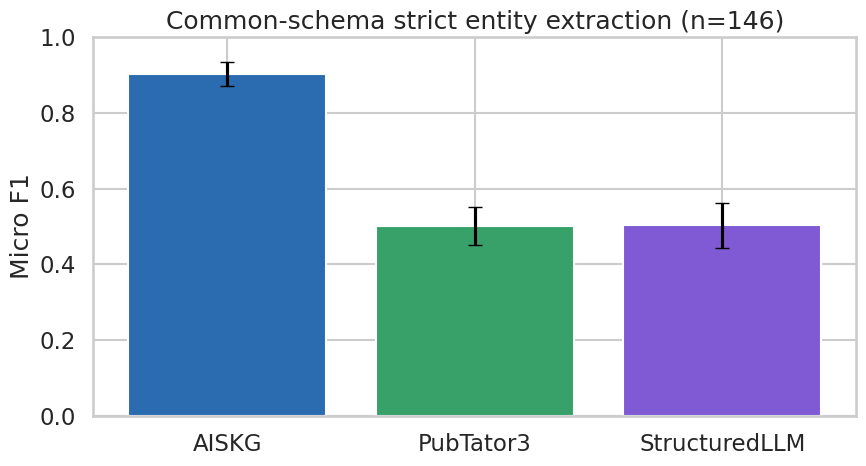

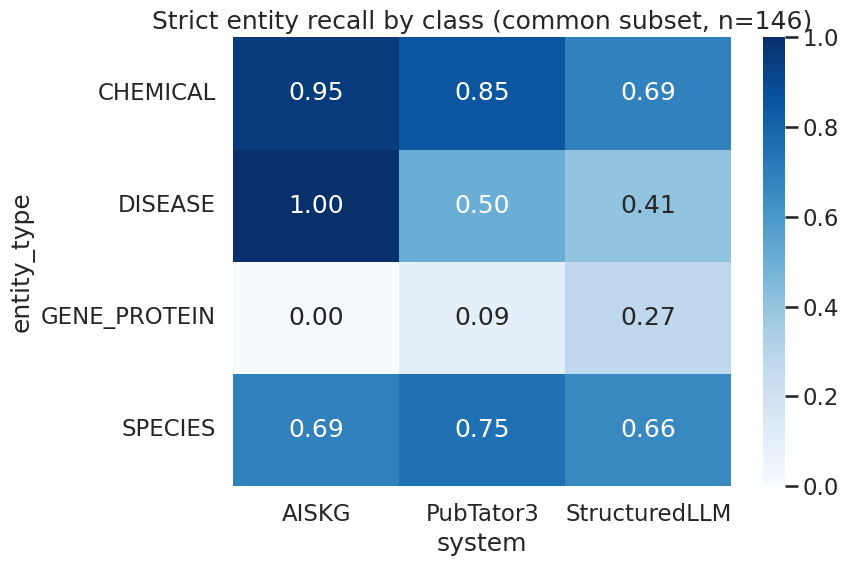

,scope,entity_type,system,n_sentences,gold_n,pred_n,tp,fp,fn,precision,recall,f1
0,COMMON_146,CHEMICAL,AISKG,146,155,163,148,15,7,0.908,0.955,0.931
1,COMMON_146,CHEMICAL,PubTator3,146,155,218,132,86,23,0.606,0.852,0.708
2,COMMON_146,CHEMICAL,StructuredLLM,146,155,185,107,78,48,0.578,0.690,0.629
3,COMMON_146,DISEASE,AISKG,146,32,32,32,0,0,1.000,1.000,1.000
4,COMMON_146,DISEASE,PubTator3,146,32,126,16,110,16,0.127,0.500,0.203
5,COMMON_146,DISEASE,StructuredLLM,146,32,74,13,61,19,0.176,0.406,0.245
6,COMMON_146,GENE_PROTEIN,AISKG,146,11,0,0,0,11,0.000,0.000,0.000
7,COMMON_146,GENE_PROTEIN,PubTator3,146,11,11,1,10,10,0.091,0.091,0.091
8,COMMON_146,GENE_PROTEIN,StructuredLLM,146,11,19,3,16,8,0.158,0.273,0.200
9,COMMON_146,SPECIES,AISKG,146,32,22,22,0,10,1.000,0.688,0.815


In [12]:
#@title 10. Correct class coverage and figures
coverage=[]
for cls in COMMON_SCHEMA:
    for name,pred in {"AISKG":aiskg_entities,"PubTator3":pub_entities,"StructuredLLM":llm_entities}.items():
        c=entity_counts(gold_entities,pred,[cls],COMMON_EVAL_IDS,"strict")
        coverage.append({"scope":"COMMON_146","entity_type":cls,"system":name,"n_sentences":146,"gold_n":int(((gold_entities.benchmark_sentence_id.isin(COMMON_EVAL_IDS))&(gold_entities.type==cls)).sum()),"pred_n":int(((pred.benchmark_sentence_id.isin(COMMON_EVAL_IDS))&(pred.type==cls)).sum()),**prf(c)})
for cls in FULL_SCHEMA:
    for name,pred in {"AISKG":aiskg_entities,"StructuredLLM":llm_entities}.items():
        c=entity_counts(gold_entities,pred,[cls],FULL_EVAL_IDS,"strict")
        coverage.append({"scope":"FULL_DOMAIN_150","entity_type":cls,"system":name,"n_sentences":150,"gold_n":int((gold_entities.type==cls).sum()),"pred_n":int((pred.type==cls).sum()),**prf(c)})
coverage=pd.DataFrame(coverage)
plot=metrics[(metrics.task=="entity")&(metrics.schema=="COMMON_146")&(metrics.criterion=="strict")]
fig,ax=plt.subplots(figsize=(9,5)); colors={"AISKG":"#2b6cb0","PubTator3":"#38a169","StructuredLLM":"#805ad5"}
ax.bar(plot.system,plot.f1,color=[colors[x] for x in plot.system]); ax.errorbar(np.arange(len(plot)),plot.f1,yerr=[plot.f1-plot.f1_ci_low,plot.f1_ci_high-plot.f1],fmt="none",ecolor="black",capsize=5)
ax.set(ylim=(0,1),ylabel="Micro F1",title="Common-schema strict entity extraction (n=146)"); fig.tight_layout(); fig.savefig(OUTPUT/"figure_common_schema_entity_f1.png",dpi=300,bbox_inches="tight"); plt.show()
piv=coverage[coverage.scope=="COMMON_146"].pivot(index="entity_type",columns="system",values="recall")
fig,ax=plt.subplots(figsize=(9,6)); sns.heatmap(piv,annot=True,fmt=".2f",vmin=0,vmax=1,cmap="Blues",ax=ax); ax.set_title("Strict entity recall by class (common subset, n=146)"); fig.tight_layout(); fig.savefig(OUTPUT/"figure_entity_class_recall.png",dpi=300,bbox_inches="tight"); plt.show()
display(coverage.round(3))


In [13]:
#@title 11. Export corrected auditable outputs and manuscript-ready text
metrics.to_csv(OUTPUT/"system_metrics.csv",index=False); paired.to_csv(OUTPUT/"paired_bootstrap_differences.csv",index=False); tests.to_csv(OUTPUT/"mcnemar_holm_tests.csv",index=False); coverage.to_csv(OUTPUT/"entity_class_coverage.csv",index=False)
gold_entities.to_csv(OUTPUT/"normalized_gold_entities.csv",index=False); gold_relations.to_csv(OUTPUT/"normalized_gold_relations.csv",index=False)
for name,df in [("aiskg_entities",aiskg_entities),("pubtator_entities",pub_entities),("llm_entities",llm_entities),("aiskg_relations",aiskg_relations),("pubtator_relations",pub_relations),("llm_relations",llm_relations)]: df.to_csv(OUTPUT/f"{name}.csv",index=False)
llm_validation.to_csv(OUTPUT/"llm_validation_log.csv",index=False)
manifest={"created_utc":datetime.now(timezone.utc).isoformat(),"repository":REPO_URL,"commit":AUDITED_COMMIT,"frozen_zip":FROZEN_ZIP,"frozen_zip_sha256":sha256_file(zip_path),"seed":SEED,"bootstrap_replicates":N_BOOT,"smoke_test":SMOKE_TEST,"n_sentences":150,"common_entity_n_sentences":146,"full_domain_n_sentences":150,"pubtator_retrieved_at":pub_bundle.get("retrieved_at"),"pubtator_sentence_coverage":len(pub_covered),"pubtator_ineligible_sentence_ids":sorted(PUBTATOR_INELIGIBLE_IDS),"pubtator_relation_status":"not_evaluable_no_relation_objects","llm_model_id":LLM_MODEL_ID,"llm_model_revision":LLM_MODEL_REVISION,"temperature":0,"prompt_sha256":hashlib.sha256(PROMPT_TEMPLATE.encode()).hexdigest(),"common_schema":COMMON_SCHEMA,"full_schema":FULL_SCHEMA,"allowed_relations":ALLOWED_RELATIONS,"relation_endpoint_normalization":"Greek-letter and whitespace normalized locked AISKG rule","python":sys.version,"pandas":pd.__version__,"numpy":np.__version__}
(OUTPUT/"run_manifest.json").write_text(json.dumps(manifest,indent=2),encoding="utf-8")
with pd.ExcelWriter(OUTPUT/"AISKG_three_system_benchmark_corrected.xlsx",engine="openpyxl") as xw:
    metrics.to_excel(xw,sheet_name="Metrics",index=False); paired.to_excel(xw,sheet_name="Paired_bootstrap",index=False); tests.to_excel(xw,sheet_name="McNemar_Holm",index=False); coverage.to_excel(xw,sheet_name="Class_coverage",index=False); llm_validation.to_excel(xw,sheet_name="LLM_validation",index=False)
def pick(system,task="entity",schema="COMMON_146",criterion="strict"):
    return metrics[(metrics.system==system)&(metrics.task==task)&(metrics.schema==schema)&(metrics.criterion==criterion)].iloc[0]
a,p,l=pick("AISKG"),pick("PubTator3"),pick("StructuredLLM"); ar=pick("AISKG","relation","FULL_DOMAIN_150","directed_strict"); lr=pick("StructuredLLM","relation","FULL_DOMAIN_150","directed_strict")
manuscript_text=(f"On the PMID-eligible common-schema subset (146 sentences; 230 gold entities), strict micro-F1 was {a.f1:.3f} for AISKG (95% CI {a.f1_ci_low:.3f}–{a.f1_ci_high:.3f}), {p.f1:.3f} for PubTator 3.0 (95% CI {p.f1_ci_low:.3f}–{p.f1_ci_high:.3f}), and {l.f1:.3f} for the structured-output LLM (95% CI {l.f1_ci_low:.3f}–{l.f1_ci_high:.3f}). Four DOI/EID-only records were excluded only from the PubTator-compatible comparison. On all 150 sentences, directed strict relation micro-F1 was {ar.f1:.3f} for AISKG (27 TP, 0 FP, 29 FN; 95% CI {ar.f1_ci_low:.3f}–{ar.f1_ci_high:.3f}) and {lr.f1:.3f} for the structured-output LLM (95% CI {lr.f1_ci_low:.3f}–{lr.f1_ci_high:.3f}). PubTator returned no usable relation objects and was therefore not assigned a relation score. The LLM produced parseable JSON for {llm_validation.json_valid.mean():.1%} of sentences. Confidence intervals used sentence-cluster bootstrap resampling; paired exact tests used sentence-level exact correctness with Holm adjustment.")
(OUTPUT/"manuscript_ready_results.txt").write_text(manuscript_text,encoding="utf-8"); print(manuscript_text)
archive=shutil.make_archive(str(ROOT/"AISKG_three_system_benchmark_corrected_outputs"),"zip",OUTPUT); print("Archive:",archive)
from google.colab import files
files.download(archive)


On the PMID-eligible common-schema subset (146 sentences; 230 gold entities), strict micro-F1 was 0.904 for AISKG (95% CI 0.871–0.934), 0.501 for PubTator 3.0 (95% CI 0.451–0.552), and 0.503 for the structured-output LLM (95% CI 0.443–0.563). Four DOI/EID-only records were excluded only from the PubTator-compatible comparison. On all 150 sentences, directed strict relation micro-F1 was 0.651 for AISKG (27 TP, 0 FP, 29 FN; 95% CI 0.400–0.804) and 0.009 for the structured-output LLM (95% CI 0.000–0.032). PubTator returned no usable relation objects and was therefore not assigned a relation score. The LLM produced parseable JSON for 100.0% of sentences. Confidence intervals used sentence-cluster bootstrap resampling; paired exact tests used sentence-level exact correctness with Holm adjustment.
Archive: /content/AISKG_three_system_benchmark/AISKG_three_system_benchmark_corrected_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Reporting checklist

Before inserting the results into the manuscript:

- Confirm `SMOKE_TEST` is `False`, the run contains 150 sentences, and the commit equals the audited hash.
- Archive the notebook, output ZIP, raw PubTator cache, LLM JSONL checkpoint, run manifest, model revision, and execution date.
- Report the common-schema comparison as the primary three-system entity analysis.
- Report AISKG-versus-LLM full-domain extraction separately.
- Do not describe endpoint-pair recovery as strict relation extraction.
- State that PubTator is a continuously updated external service and give the retrieval date.
- Do not select prompts, models, mappings, or thresholds based on held-out results. Any post-hoc change requires a new development set and a fresh frozen test.

### Suggested Methods wording

“We conducted a prespecified comparison on the same frozen 150-sentence held-out corpus. AISKG outputs were loaded from the audited repository commit without re-tuning. PubTator 3.0 annotations were retrieved by PMID from the official NCBI service and projected onto the frozen sentence boundaries. A zero-shot instruction model generated ontology-constrained JSON at temperature 0; predictions were accepted only when entity mentions were verbatim sentence spans and relation arguments referred to accepted entities. The primary three-system entity comparison was restricted to mutually supported entity classes, while full-domain AISKG and LLM results were reported separately. We calculated micro-averaged precision, recall and F1, sentence-cluster bootstrap 95% confidence intervals, paired bootstrap F1 differences, and exact McNemar tests on sentence-level exact correctness with Holm adjustment.”